<a href="https://colab.research.google.com/github/darreneasler/MiniProject1/blob/main/MiniProject1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [120]:
# COLAB SETUP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("pandas", pd.__version__)

import gdown

file_id = "1ZukiI6Z03KP_4tqTgMKcHCENoiixQR9p"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "data.csv", quiet=False)


pandas 2.2.2


Downloading...
From: https://drive.google.com/uc?id=1ZukiI6Z03KP_4tqTgMKcHCENoiixQR9p
To: /content/data.csv
100%|██████████| 45.6M/45.6M [00:00<00:00, 54.6MB/s]


'data.csv'

In [121]:
#3.2 Getting information

dataset = pd.read_csv('data.csv', encoding='ISO-8859-1')
print(dataset.shape)
dataset.head(5)
dataset.info()
dataset.describe()

missing_vals = dataset.isnull().sum()
missing_vals[missing_vals > 0]
for col, count in missing_vals.items():
  print(f"{col}: {count} misssing values.")


(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
InvoiceNo: 0 misssing values.
StockCode: 0 misssing values.
Description: 1454 misssing values.
Quantity: 0 misssing values.
InvoiceDate: 0 misssing values.
UnitPrice: 0 misssing values.
CustomerID: 135080 misssing values.
Country: 0 misssing values.


In [122]:
#3.9 Unique values

print(dataset["Country"].value_counts(dropna = False))
print("Unique Countries:", dataset["Country"].nunique())

print(dataset["StockCode"].value_counts(dropna = False))
print("Unique Stock Codes:", dataset["StockCode"].nunique())

print(dataset["Description"].value_counts(dropna = False))
print("Unique Descriptions:", dataset["Description"].nunique())

missing_num = dataset["Description"].isna().sum()
print(f"Missing Descriptions: {missing_num}")


Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [123]:
#3.8 Min/max/sum/mean/count

dataset[["Quantity", "UnitPrice"]].describe()
dataset['revenue'] = dataset['Quantity']*dataset['UnitPrice']

returns = dataset[dataset["Quantity"] < 0]
print("Number of returns:", len(returns))

invalid_sales = dataset[dataset["UnitPrice"] <= 0]
print("Number of invalid sales:", len(invalid_sales))

Number of returns: 10624
Number of invalid sales: 2517


In [124]:
#3.1 Creating a DataFrame

dataset["Country"].value_counts()

country_modify = {
    "United Kingdom": "UK & Ireland",
    "EIRE": "UK & Ireland",
    "France": "Western Europe",
    "Germany": "Western Europe",
    "Netherlands": "Western Europe",
    "Belgium": "Western Europe",
    "Spain": "Southern Europe",
    "Portugal": "Southern Europe",
    "Italy": "Southern Europe",
    "Switzerland": "Southern Europe",
    "Norway": "Northern Europe",
    "Sweden": "Northern Europe",
    "Finland": "Northern Europe",
    "Denmark": "Northern Europe",
    "Australia": "Asia/Oceania",
    "Japan": "Asia/Oceania",
    "Singapore": "Asia/Oceania",
    "Hong Kong": "Asia/Oceania",
    "USA": "North America",
    "Canada": "North America",
    "Channel Islands": "UK & Ireland",
    "Cyprus": "Middle Eastern",
    "Austria": "Western Europe",
    "Poland": "Western Europe",
    "Israel": "Middle Eastern",
    "Iceland": "Northern Europe",
    "Greece": "Southern Europe",
    "Brazil": "South America",
    "Malta": "Southern Europe",
    "Saudi Arabia": "Middle Eastern",
    "Czech Republic": "Western Europe",
    "Bahrain": "Middle Eastern",
    "United Arab Emirates": "Middle Eastern",
    "RSA": "Africa",
    "Lebanon": "Middle Eastern",
    "Lithuania": "Northern Europe",
    "European Community": "Western Europe",
    "Unspecified": "Missing",
    "South Africa": "Africa",
    "Ireland": "UK & Ireland",
    "Missing": "Missing"
}

country_mapping = pd.DataFrame(country_modify.items(), columns=["Country", "Region"])
country_mapping.head()

,Country,Region
0,United Kingdom,UK & Ireland
1,EIRE,UK & Ireland
2,France,Western Europe
3,Germany,Western Europe
4,Netherlands,Western Europe


In [125]:
#3.3 Slicing

dataset.iloc[1:5]

dataset['LineItemIndex'] = dataset['InvoiceNo'].astype(str) + '_' + (dataset.groupby('InvoiceNo').cumcount() + 1).astype(str)
dataset = dataset.set_index('LineItemIndex')

dataset.loc['536401_5']


,536401_5
InvoiceNo,536401
StockCode,22451
Description,SILK PURSE BABUSHKA RED
Quantity,1
InvoiceDate,12/1/2010 11:21
UnitPrice,3.35
CustomerID,15862.0
Country,United Kingdom
revenue,3.35


In [126]:
#3.4 Conditional selection

cancels = dataset[dataset['InvoiceNo'].astype(str).str.startswith('C')]
neg_qty = dataset[dataset['Quantity'] <= 0]
neg_price = dataset[dataset['UnitPrice'] <= 0]

print(f"Canceled orders: {len(*[cancels])}")
print(f"Negative Qty: {len(*[neg_qty])}")
print(f"Negative price: {len(*[neg_price])}")





Canceled orders: 9288
Negative Qty: 10624
Negative price: 2517


In [127]:
#3.5 Sorting values

dataset['LineRevenue'] = dataset['Quantity'] * dataset['UnitPrice']
biggest_orders = dataset.sort_values('Quantity', ascending=False)
biggest_returns = dataset.sort_values('Quantity', ascending=True)
biggest_revenue = dataset.sort_values('LineRevenue', ascending=False)
biggest_return_prices = dataset.sort_values('LineRevenue', ascending=True)

print(f"Largest orders:\n{biggest_orders.head(1)}")
print(f"Largest returns:\n{biggest_returns.head(1)}")
print(f"Largest revenue:\n{biggest_revenue.head(1)}")
print(f"Largest return price:\n{biggest_return_prices.head(1)}")




Largest orders:
              InvoiceNo StockCode                  Description  Quantity  \
LineItemIndex                                                              
581483_1         581483     23843  PAPER CRAFT , LITTLE BIRDIE     80995   

                  InvoiceDate  UnitPrice  CustomerID         Country  \
LineItemIndex                                                          
581483_1       12/9/2011 9:15       2.08     16446.0  United Kingdom   

                revenue  LineRevenue  
LineItemIndex                         
581483_1       168469.6     168469.6  
Largest returns:
              InvoiceNo StockCode                  Description  Quantity  \
LineItemIndex                                                              
C581484_1       C581484     23843  PAPER CRAFT , LITTLE BIRDIE    -80995   

                  InvoiceDate  UnitPrice  CustomerID         Country  \
LineItemIndex                                                          
C581484_1      12/9/2011 9:27  

In [128]:
#3.6 Replacing values

dataset['Country'] = dataset['Country'].replace({'EIRE': 'Ireland', 'RSA': 'South Africa', 'Unspecified': 'Missing'})
dataset['Country'].value_counts()



,count
Country,
United Kingdom,495478
Germany,9495
France,8557
Ireland,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


In [129]:
#3.7 Renaming columns

dataset = dataset.rename(columns=
                         {
                             'LineItemID': 'line_item_index',
                             'LineRevenue': 'line_revenue',
                             'InvoiceNo': 'invoice_number',
                             'StockCode': 'stock_code',
                             'Description': 'description',
                             'Quantity': 'quantity',
                             'InvoiceDate': 'invoice_date',
                             'UnitPrice': 'unit_price',
                             'CustomerID': 'customer_id',
                             'Country': 'country'
                         })
dataset.head()

,invoice_number,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue,line_revenue
LineItemIndex,,,,,,,,,,
536365_1,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30,15.30
536365_2,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,20.34
536365_3,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00,22.00
536365_4,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,20.34
536365_5,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,20.34


In [130]:
#3.10 Handling missing values

missing_data = dataset.isnull().sum()
missing_pct = (missing_data / len(dataset) * 100).round(2)
print(pd.DataFrame({'missing_count': missing_data, 'missing_%': missing_pct}))

dataset=dataset.dropna(subset=['description'])

dataset['customer_id'] = dataset['customer_id'].fillna('NO_ID')

print()
print(dataset.isnull().sum())

                missing_count  missing_%
invoice_number              0       0.00
stock_code                  0       0.00
description              1454       0.27
quantity                    0       0.00
invoice_date                0       0.00
unit_price                  0       0.00
customer_id            135080      24.93
country                     0       0.00
revenue                     0       0.00
line_revenue                0       0.00

invoice_number    0
stock_code        0
description       0
quantity          0
invoice_date      0
unit_price        0
customer_id       0
country           0
revenue           0
line_revenue      0
dtype: int64


In [131]:
#3.11 Deleting a column

dataset = dataset.reset_index(drop=True)

In [132]:
#3.12 Deleting a row

false_codes = ['POST', 'DOT', 'M', 'm', 'BANK CHARGES', 'AMAZONFEE', 'CRUK', 'D', 'PADS', 'C2', 'gift_0001_20', 'gift_0001_10', 'gift_0001_30', 'gift_0001_50', 'gift_0001_40', 'B']
clean_sales = dataset[~dataset['invoice_number'].astype(str).str.startswith('C')]
clean_sales = clean_sales[~clean_sales['stock_code'].isin(false_codes)]
clean_sales = clean_sales[clean_sales['quantity'] > 0]
clean_sales = clean_sales[clean_sales['unit_price'] > 0]
clean_sales = clean_sales[clean_sales['description'].notna()]

print(clean_sales.isnull().sum())
print(clean_sales.describe())


invoice_number    0
stock_code        0
description       0
quantity          0
invoice_date      0
unit_price        0
customer_id       0
country           0
revenue           0
line_revenue      0
dtype: int64
            quantity     unit_price        revenue   line_revenue
count  527760.000000  527760.000000  527760.000000  527760.000000
mean       10.567497       3.265530      19.462438      19.462438
std       155.834122       4.378283     268.605188     268.605188
min         1.000000       0.040000       0.060000       0.060000
25%         1.000000       1.250000       3.750000       3.750000
50%         3.000000       2.080000       9.900000       9.900000
75%        11.000000       4.130000      17.400000      17.400000
max     80995.000000     649.500000  168469.600000  168469.600000


In [133]:
#3.13 Dropping duplicates

duplicate_count = clean_sales.duplicated().sum()
print(f"Duplicate rows detected: {duplicate_count}")

row_count0 = len(clean_sales)

clean_sales = clean_sales.drop_duplicates()
row_count1 = len(clean_sales)

print(f"Dropped rows: {row_count0 - row_count1}")

Duplicate rows detected: 5221
Dropped rows: 5221


In [134]:
#3.18 Applying a function

clean_sales['revenue'] = clean_sales['quantity'] * clean_sales['unit_price']

def clean_description(des):
  if pd.isna(des):
    return des
  return des.strip().title()

clean_sales['description_clean'] = clean_sales['description'].apply(clean_description)

def canceled_order(inv):
  return str(inv).startswith('C')

clean_sales['cancel_order'] = clean_sales['invoice_number'].apply(canceled_order)

clean_sales.head(10)


,invoice_number,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue,line_revenue,description_clean,cancel_order
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30,15.30,White Hanging Heart T-Light Holder,False
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,20.34,White Metal Lantern,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00,22.00,Cream Cupid Hearts Coat Hanger,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,20.34,Knitted Union Flag Hot Water Bottle,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,20.34,Red Woolly Hottie White Heart.,False
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom,15.30,15.30,Set 7 Babushka Nesting Boxes,False
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom,25.50,25.50,Glass Star Frosted T-Light Holder,False
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom,11.10,11.10,Hand Warmer Union Jack,False
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom,11.10,11.10,Hand Warmer Red Polka Dot,False
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom,54.08,54.08,Assorted Colour Bird Ornament,False


In [135]:
#3.17 Looping over a column
dataset_copy = dataset.copy()

dataset_copy['descreiption_clean1'] = [clean_description(des) for des in dataset_copy['description']]
dataset_copy.head(10)

,invoice_number,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue,line_revenue,descreiption_clean1
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30,15.30,White Hanging Heart T-Light Holder
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,20.34,White Metal Lantern
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00,22.00,Cream Cupid Hearts Coat Hanger
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,20.34,Knitted Union Flag Hot Water Bottle
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,20.34,Red Woolly Hottie White Heart.
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom,15.30,15.30,Set 7 Babushka Nesting Boxes
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom,25.50,25.50,Glass Star Frosted T-Light Holder
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom,11.10,11.10,Hand Warmer Union Jack
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom,11.10,11.10,Hand Warmer Red Polka Dot
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom,54.08,54.08,Assorted Colour Bird Ornament


In [136]:
#3.14 Grouping by values

rev_country = clean_sales.groupby('country')['revenue'].sum().sort_values(ascending=False)
print(rev_country)

customer_orders = clean_sales.groupby('customer_id')['invoice_number'].nunique().sort_values(ascending=False)
print()
print(customer_orders)


country
United Kingdom          8724506.72
Netherlands              283889.34
Ireland                  270850.86
Germany                  205381.15
France                   184493.00
Australia                138103.81
Spain                     55706.56
Switzerland               53065.60
Japan                     37416.37
Belgium                   36927.34
Sweden                    36828.83
Norway                    32454.64
Portugal                  26951.11
Channel Islands           19997.54
Finland                   18344.88
Denmark                   18211.34
Italy                     15820.24
Cyprus                    13167.16
Hong Kong                  9744.19
Singapore                  9120.39
Austria                    8742.68
Israel                     8129.41
Poland                     6974.65
Missing                    4740.94
Greece                     4425.52
Iceland                    4310.00
USA                        3580.39
Canada                     3115.44
Malta       

In [137]:
#3.15 Aggregating

invoice_index = clean_sales.groupby('invoice_number').agg(order_revenue=('revenue', 'sum'), country=('country', 'first'), customer_id=('customer_id', 'first')).reset_index()

country_summary = invoice_index.groupby('country').agg(total_revenue=('order_revenue', 'sum'), mean_order_value=('order_revenue', 'mean'), transaction_count=('invoice_number', 'nunique')).sort_values('total_revenue', ascending=False)
customer_summary = invoice_index.groupby('customer_id').agg(total_revenue=('order_revenue', 'sum'), mean_order_value=('order_revenue', 'mean'), transaction_count=('invoice_number', 'nunique')).sort_values('total_revenue', ascending=False)

print(country_summary)
print()
print(customer_summary)

                      total_revenue  mean_order_value  transaction_count
country                                                                 
United Kingdom           8724506.72        487.320936              17903
Netherlands               283889.34       3052.573548                 93
Ireland                   270850.86        960.464043                282
Germany                   205381.15        463.614334                443
France                    184493.00        482.965969                382
Australia                 138103.81       2466.139464                 56
Spain                      55706.56        633.029091                 88
Switzerland                53065.60       1061.312000                 50
Japan                      37416.37       1969.282632                 19
Belgium                    36927.34        376.809592                 98
Sweden                     36828.83       1083.200882                 34
Norway                     32454.64       1014.2075

In [138]:
#3.19 Applying to groups

clean_sales['invoice_date'] = pd.to_datetime(clean_sales['invoice_date'])
def data_summary(var):
  return pd.Series({'total_spend': var['revenue'].sum(), 'active_months': var['invoice_date'].dt.to_period('M').nunique(),
                    'number_orders': var['invoice_number'].nunique(), 'first_order': var['invoice_date'].min(),
                    'last_order': var['invoice_date'].max()})
each_customer = clean_sales.groupby('customer_id').apply(data_summary)
each_customer.head(10)


/tmp/ipykernel_16494/3213028715.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  each_customer = clean_sales.groupby('customer_id').apply(data_summary)


,total_spend,active_months,number_orders,first_order,last_order
customer_id,,,,,
12346.0,77183.60,1,1,2011-01-18 10:01:00,2011-01-18 10:01:00
12347.0,4310.00,7,7,2010-12-07 14:57:00,2011-12-07 15:52:00
12348.0,1437.24,4,4,2010-12-16 19:09:00,2011-09-25 13:13:00
12349.0,1457.55,1,1,2011-11-21 09:51:00,2011-11-21 09:51:00
12350.0,294.40,1,1,2011-02-02 16:01:00,2011-02-02 16:01:00
12352.0,1385.74,4,7,2011-02-16 12:33:00,2011-11-03 14:37:00
12353.0,89.00,1,1,2011-05-19 17:47:00,2011-05-19 17:47:00
12354.0,1079.40,1,1,2011-04-21 13:11:00,2011-04-21 13:11:00
12355.0,459.40,1,1,2011-05-09 13:49:00,2011-05-09 13:49:00


In [139]:
#3.15 Grouping by time

clean_sales = clean_sales.set_index('invoice_date', drop=False)

monthly_revenue = clean_sales.resample('M')['revenue'].sum()
weekly_revenue = clean_sales.resample('W')['revenue'].sum()

print(monthly_revenue)
print()
print(weekly_revenue)



invoice_date
2010-12-31     775638.36
2011-01-31     670380.24
2011-02-28     507799.87
2011-03-31     689833.51
2011-04-30     515407.99
2011-05-31     739953.00
2011-06-30     737558.98
2011-07-31     688219.34
2011-08-31     724216.50
2011-09-30    1028320.38
2011-10-31    1103347.30
2011-11-30    1452115.98
2011-12-31     614490.92
Freq: ME, Name: revenue, dtype: float64

invoice_date
2010-12-05    180736.32
2010-12-12    301082.39
2010-12-19    208616.61
2010-12-26     85203.04
2011-01-02         0.00
2011-01-09    130274.65
2011-01-16    187291.30
2011-01-23    209331.26
2011-01-30    121001.73
2011-02-06    121351.11
2011-02-13    103570.49
2011-02-20    140305.11
2011-02-27    145237.07
2011-03-06    127588.35
2011-03-13    129034.74
2011-03-20    153340.36
2011-03-27    144841.46
2011-04-03    186550.75
2011-04-10    122784.05
2011-04-17    146043.11
2011-04-24    138298.14
2011-05-01     83392.04
2011-05-08    136790.86
2011-05-15    204717.07
2011-05-22    210335.39
2011-05-

/tmp/ipykernel_16494/3977484320.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = clean_sales.resample('M')['revenue'].sum()


In [140]:
#3.20 Concatenating

first_half = clean_sales.loc[clean_sales.index < "2011-07-01"]
second_half = clean_sales.loc[clean_sales.index >= "2011-07-01"]

merged_sales = pd.concat([first_half, second_half])

original = clean_sales.sort_index()
merged = merged_sales.sort_index()

print(original.equals(merged))


True


In [141]:
#3.21 Merging

country_mapping = pd.DataFrame(country_modify.items(), columns=["country", "region"])

clean_sales = clean_sales.merge(country_mapping, on="country",how="left")

missing = clean_sales[clean_sales["region"].isna()]["country"].unique()
print(missing)


[]


Total revenue: 10247282.37

Monthly revenue: invoice_date
2010-12-31     775638.36
2011-01-31     670380.24
2011-02-28     507799.87
2011-03-31     689833.51
2011-04-30     515407.99
2011-05-31     739953.00
2011-06-30     737558.98
2011-07-31     688219.34
2011-08-31     724216.50
2011-09-30    1028320.38
2011-10-31    1103347.30
2011-11-30    1452115.98
2011-12-31     614490.92
Freq: ME, Name: revenue, dtype: float64

Peak month: 2011-11-30 00:00:00

Peak revenue: 1452115.98


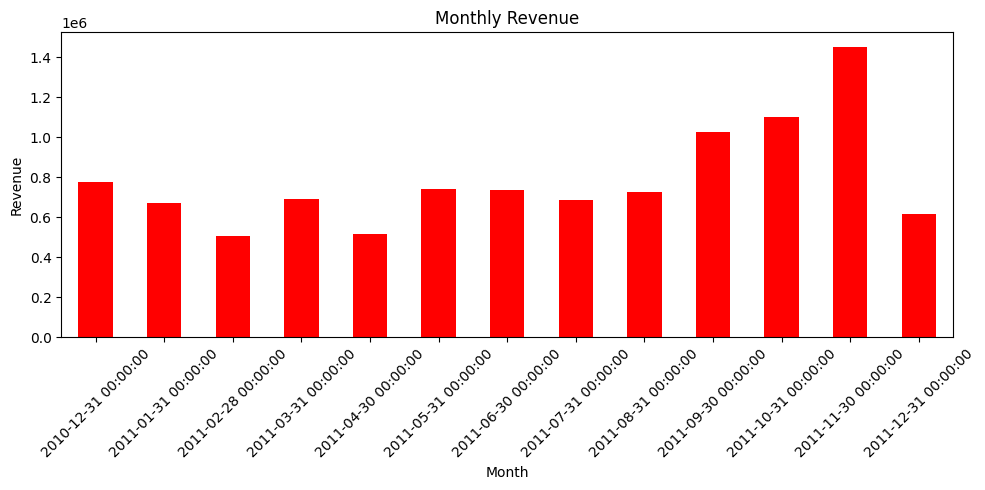

   Month       Revenue
Dec 2010   $775,638.36
Jan 2011   $670,380.24
Feb 2011   $507,799.87
Mar 2011   $689,833.51
Apr 2011   $515,407.99
May 2011   $739,953.00
Jun 2011   $737,558.98
Jul 2011   $688,219.34
Aug 2011   $724,216.50
Sep 2011 $1,028,320.38
Oct 2011 $1,103,347.30
Nov 2011 $1,452,115.98
Dec 2011   $614,490.92


In [142]:
# Seasonality

total_revenue = clean_sales['revenue'].sum()
print(f"Total revenue: {total_revenue}")
print()
clean_sales = clean_sales.set_index('invoice_date')
monthly_revenue = clean_sales["revenue"].resample("ME").sum()
print(f"Monthly revenue: {monthly_revenue}")
print()
peak_month = monthly_revenue.idxmax()
peak_value = monthly_revenue.max()

print(f"Peak month: {peak_month}")
print()
print(f"Peak revenue: {peak_value}")

plt.figure(figsize=(10, 5))

monthly_revenue.plot(kind="bar", color="red")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

monthly_table = monthly_revenue.reset_index()
monthly_table.columns = ["Month", "Revenue"]

monthly_table["Month"] = monthly_table["Month"].dt.strftime("%b %Y")
monthly_table["Revenue"] = monthly_table["Revenue"].map("${:,.2f}".format)

print(monthly_table.to_string(index=False))

Top 10 products by revenue:
                                   description  total_revenue
stock_code                                                   
22423                 REGENCY CAKESTAND 3 TIER      174156.54
23843              PAPER CRAFT , LITTLE BIRDIE      168469.60
85123A      WHITE HANGING HEART T-LIGHT HOLDER      104462.75
47566                            PARTY BUNTING       99445.23
85099B                 JUMBO BAG RED RETROSPOT       94159.81
23166           MEDIUM CERAMIC TOP STORAGE JAR       81700.92
23084                       RABBIT NIGHT LIGHT       66870.03
22086          PAPER CHAIN KIT 50'S CHRISTMAS        64875.59
84879            ASSORTED COLOUR BIRD ORNAMENT       58927.62
79321                            CHILLI LIGHTS       54096.36


Top 10 products by units sold:
                                   description  total_units
stock_code                                                 
23843              PAPER CRAFT , LITTLE BIRDIE        80995
23166          

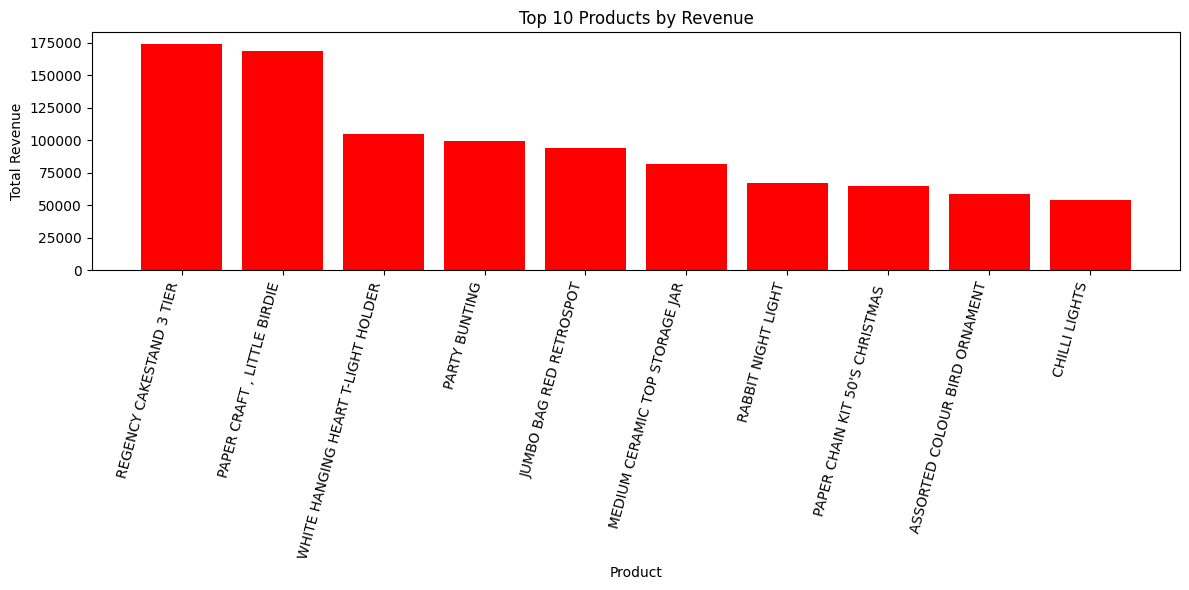

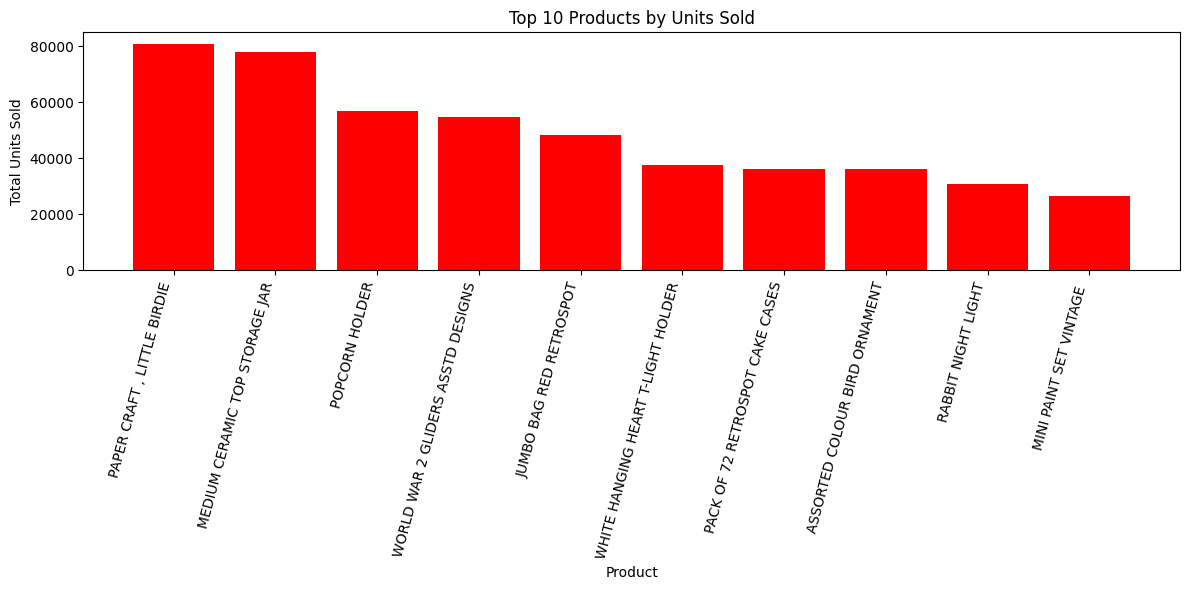

In [149]:
# Best Sellers

product_summary = clean_sales.groupby('stock_code').agg(description=('description', lambda x: x.mode()[0]), total_revenue=('revenue', 'sum'), total_units=('quantity', 'sum'))

top10_revenue = product_summary.sort_values('total_revenue', ascending=False).head(10)
top10_units = product_summary.sort_values('total_units', ascending=False).head(10)

print("Top 10 products by revenue:")
print(top10_revenue[['description', 'total_revenue']])
print()

print("\nTop 10 products by units sold:")
print(top10_units[['description', 'total_units']])
print()

overlap = set(top10_revenue.index) & set(top10_units.index)
only_revenue = set(top10_revenue.index) - set(top10_units.index)
only_units = set(top10_units.index) - set(top10_revenue.index)

print(f"\nProducts in both top-10 lists: {len(overlap)}")
print("Only in top revenue:", product_summary.loc[list(only_revenue), 'description'].tolist())
print("Only in top units:", product_summary.loc[list(only_units), 'description'].tolist())

plt.figure(figsize=(12,6))
plt.bar(top10_revenue['description'], top10_revenue['total_revenue'], color='red')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

# Top 10 Products by Units Sold
plt.figure(figsize=(12,6))
plt.bar(top10_units['description'], top10_units['total_units'], color='red')
plt.title('Top 10 Products by Units Sold')
plt.xlabel('Product')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

In [144]:
# Markets

country_mapping = pd.DataFrame(country_modify.items(), columns=["country", "region"])

if 'region' in clean_sales.columns:
    clean_sales = clean_sales.drop(columns=['region'])

markets = clean_sales.merge(country_mapping, on='country', how='left')

markets = clean_sales.merge(country_mapping, on='country', how='left')
unmatched = markets['region'].isna().sum()
print(f"Rows with no matching region after merge: {unmatched}")
if unmatched > 0:
    print("Unmatched countries:", markets.loc[markets['region'].isna(), 'country'].unique())

non_uk = markets[markets['country'] != 'United Kingdom']

country_summary = non_uk.groupby('country').agg(
    total_revenue=('revenue', 'sum'),
    distinct_customers=('customer_id', 'nunique')
).sort_values('total_revenue', ascending=False)
country_summary['revenue_per_customer'] = (
    country_summary['total_revenue'] / country_summary['distinct_customers']
).round(2)

print()
print("\nTop 10 non-UK countries by revenue")
print(country_summary.head(10))

print()
print("Top 10 non-UK countries by distinct customers")
print(country_summary.sort_values('distinct_customers', ascending=False).head(10))


region_summary = non_uk.groupby('region').agg(
    total_revenue=('revenue', 'sum'),
    distinct_customers=('customer_id', 'nunique')
).sort_values('total_revenue', ascending=False)
region_summary['revenue_per_customer'] = (
    region_summary['total_revenue'] / region_summary['distinct_customers']
).round(2)

print()
print("Non-UK regions by revenue")
print(region_summary)


top_country = country_summary.index[0]
top_country_rev = country_summary.iloc[0]['total_revenue']
top_country_cust = int(country_summary.iloc[0]['distinct_customers'])

top_region = region_summary.index[0]
top_region_rev = region_summary.iloc[0]['total_revenue']

by_breadth = country_summary.sort_values('distinct_customers', ascending=False)
broadest_country = by_breadth.index[0]
broadest_cust = int(by_breadth.iloc[0]['distinct_customers'])
broadest_rev = by_breadth.iloc[0]['total_revenue']



Rows with no matching region after merge: 0


Top 10 non-UK countries by revenue
             total_revenue  distinct_customers  revenue_per_customer
country                                                             
Netherlands      283889.34                   9              31543.26
Ireland          270850.86                   4              67712.72
Germany          205381.15                  94               2184.91
France           184493.00                  88               2096.51
Australia        138103.81                   9              15344.87
Spain             55706.56                  30               1856.89
Switzerland       53065.60                  22               2412.07
Japan             37416.37                   8               4677.05
Belgium           36927.34                  25               1477.09
Sweden            36828.83                   8               4603.60

Top 10 non-UK countries by distinct customers
             total_revenue  distinct_custome

In [145]:
# Customer Concentration
customer_list = clean_sales[clean_sales['customer_id'] != 'NO_ID']


customer_spend = customer_list.groupby('customer_id')['revenue'].sum().sort_values(ascending=False)
total_revenue = customer_spend.sum()
total_customers = len(customer_spend)


top_10 = customer_spend.head(10)

top1pct_n = max(1, round(total_customers * 0.01))
top1pct_share = customer_spend.head(top1pct_n).sum() / total_revenue * 100
rounded = top1pct_share.round(2)

print(top_10)
print(f"Top 1%: {rounded}%")


customer_id
14646.0    279138.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    136161.83
12415.0    124564.53
14156.0    116560.08
17511.0     91062.38
12346.0     77183.60
16029.0     72708.09
Name: revenue, dtype: float64
Top 1%: 31.99%


In [146]:
# Order Value

invoice_level = clean_sales.groupby('invoice_number').agg(order_revenue=('revenue', 'sum'), country=('country', 'first')).reset_index()

invoice_level['is_uk'] = invoice_level['country'] == 'United Kingdom'

avg_order_value = invoice_level.groupby('is_uk')['order_revenue'].agg(['mean', 'median', 'count'])
avg_order_value.index = avg_order_value.index.map({True: 'UK', False: 'Non-UK'})
avg_order_value.index.name = 'Region'
avg_order_value.columns = ['Avg Order Value', 'Median Order Value', '# of Orders']
avg_order_value = avg_order_value.round(2)

print(avg_order_value)

        Avg Order Value  Median Order Value  # of Orders
Region                                                  
Non-UK           813.45              385.28         1872
UK               487.32              299.60        17903


In [147]:
# Returns & Cancellations

cancellations = dataset[dataset['invoice_number'].astype(str).str.startswith('C')].copy()
cancellations['revenue'] = cancellations['quantity'] * cancellations['unit_price']

cancel_rate_rows = len(cancellations) / len(dataset) * 100
cancel_rate_invoices = cancellations['invoice_number'].nunique() / dataset['invoice_number'].nunique() * 100

cancel_value_pct = abs(cancellations['revenue'].sum()) / dataset[dataset['revenue']>0]['revenue'].sum() * 100

product_cancels = cancellations[~cancellations['stock_code'].isin(false_codes)].groupby('stock_code').agg(
    description=('description', lambda x: x.mode()[0]),
    cancel_count=('quantity', 'count'),
    cancel_value=('revenue', 'sum')
)

customer_cancels = cancellations.dropna(subset=['customer_id']).groupby('customer_id').agg(
    cancel_count=('quantity', 'count'),
    cancel_value=('revenue', 'sum')
)
print(cancel_rate_rows)
print()
print(cancel_value_pct)
print()
print(product_cancels.sort_values('cancel_value', ascending=True).head(10))
print()
print(customer_cancels.sort_values('cancel_value', ascending=True).head(10))
print()
print(product_cancels.sort_values('cancel_count', ascending=False).head(10))
print()
print(customer_cancels.sort_values('cancel_count', ascending=False).head(10))

1.7185519608478041

8.407603002607368

                                   description  cancel_count  cancel_value
stock_code                                                                
23843              PAPER CRAFT , LITTLE BIRDIE             1    -168469.60
23166           MEDIUM CERAMIC TOP STORAGE JAR            10     -77479.64
22423                 REGENCY CAKESTAND 3 TIER           181      -9722.55
85123A      WHITE HANGING HEART T-LIGHT HOLDER            42      -6624.30
21108       FAIRY CAKE FLANNEL ASSORTED COLOUR             3      -6591.42
23113                    PANTRY CHOPPING BOARD             6      -4803.06
48185                       DOORMAT FAIRY CAKE             3      -4554.90
21175              GIN + TONIC DIET METAL SIGN             7      -3775.33
47566B                  TEA TIME PARTY BUNTING             7      -3692.95
22273                     FELTCRAFT DOLL MOLLY             6      -3512.65

             cancel_count  cancel_value
customer_id         

In [148]:
# Data-quality Memo

dataset['reason'] = None

# Assign each row to the FIRST matching reason, in priority order
dataset.loc[dataset['invoice_number'].astype(str).str.startswith('C'), 'reason'] = 'cancellation'
dataset.loc[dataset['reason'].isna() & dataset['stock_code'].isin(false_codes), 'reason'] = 'non_product_code'
dataset.loc[dataset['reason'].isna() & (dataset['quantity'] <= 0), 'reason'] = 'bad_quantity'
dataset.loc[dataset['reason'].isna() & (dataset['unit_price'] <= 0), 'reason'] = 'bad_price'
dataset.loc[dataset['reason'].isna() & dataset['description'].isna(), 'reason'] = 'missing_description'

still_in = dataset[dataset['reason'].isna()]
dup_mask = still_in.duplicated()
dataset.loc[still_in[dup_mask].index, 'reason'] = 'duplicate'

print(dataset['reason'].value_counts())


reason
cancellation        9288
duplicate           5221
non_product_code    2356
bad_price            577
bad_quantity         474
Name: count, dtype: int64


In [150]:
clean_online_resale = clean_sales.copy()

clean_online_resale.to_csv('clean_online_resale.csv', index=False)